# Epic of Sun - Desafio 1
Training the FPN model.
***

This jupyter notebook trains a FPN for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the datasets in training and validation
* Build the model
* Train the model
* Evaluate the training

***

## Loading libraries and data

In [26]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import random
import math

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
#import joblib
from pathlib import Path
#import os

import tensorflow as tf
#from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from keras import layers
from keras.models import Model
#from keras.models import load_model

#import keras_tuner as kt

In [27]:
# Flags
flag_load_hyperparams = False
include_swir = False  # Set to True if you want to include SWIR bands

In [28]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [29]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

# Specify the path to the TFRecords directory
tfrecord_path = base_path / "data" / "tfrecords"

In [30]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene01         0          0          0   
1  scene01         1          0         64   
2  scene01         2          0        128   
3  scene01         3          0        192   
4  scene01         4          0        256   

                                   x_patch_path  \
0  data/processed/scene01/images/patch_0000.npy   
1  data/processed/scene01/images/patch_0001.npy   
2  data/processed/scene01/images/patch_0002.npy   
3  data/processed/scene01/images/patch_0003.npy   
4  data/processed/scene01/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene01/masks/patch_0000.npy              8434  
1  data/processed/scene01/masks/patch_0001.npy             12836  
2  data/processed/scene01/masks/patch_0002.npy              9355  
3  data/processed/scene01/masks/patch_0003.npy              3983  
4  data/processed/scene01/masks/patch_0004.npy               805  
44890


## Selecting datasets in training and validation

In [ ]:
# Load the best hyperparameters from the JSON file
if flag_load_hyperparams:
	json_path = base_path / "models" / "fpn" / "fpn_best_hyperparams.json"

	with open(json_path, "r") as f:
		saved_params = json.load(f)
	print("Loaded hyperparameters from JSON:")
	print(saved_params)
else:
	saved_params = {
		"init_filters": 32,
		"batch_size": 64,
		"lr": 0.00005
	}
	print("Hyperparameters not loaded from JSON. Using default values:")
	print(saved_params)

Hyperparameters not loaded from JSON. Using default values:
{'init_filters': 32, 'batch_size': 64, 'lr': 5e-05}


In [32]:
# Load the count JSON file
with open(tfrecord_path / "counts.json") as f:
    counts = json.load(f)

n_train, n_val, n_test = counts["train"], counts["val"], counts["test"]

In [33]:
# Functions to create TensorFlow datasets for training, validation, and testing

def _parse_example(example_proto, include_swir=include_swir):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
        "scene": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)

    # Set the shape of the tensors based on whether SWIR bands are included
    if include_swir:
        x.set_shape((128, 128, 6))  # 6 bands
    else:
        x.set_shape((128, 128, 4))  # 4 bands
    y.set_shape((128, 128, 1))

    """
     If the SWIR bands are include but you only want to use the first 4 bands 
     (Blue, Green, Red, NIR), you can slice the tensor as follows:
    # 1. Always set the shape to 6 because that is how it was saved in the TFRecord
    x.set_shape((128, 128, 6))  
    y.set_shape((128, 128, 1))
    # 2. Slice the tensor if you only want to use the first 4 bands (Blue, Green, Red, NIR)
    if not include_swir:
        x = x[..., :4]  # Keeps only channels 0, 1, 2, and 3"""

    scene = parsed["scene"]
    return x, y, scene

def _augment(x, y, scene):
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)
    factor = tf.random.uniform((), 0.9, 1.1)
    x = tf.clip_by_value(x * factor, 0.0, 1.0)
    return x, y, scene

def _add_indices(x, y, scene, include_swir=include_swir):
    if include_swir:
        blue, green, red, nir, swir1, swir2 = x[..., 0], x[..., 1], x[..., 2], x[..., 3], x[..., 4], x[..., 5]
    else:
        blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    if include_swir:
        x = tf.stack([blue, green, red, nir, swir1, swir2, ndvi, ndwi, evi], axis=-1)
    else:
        x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)

    return x, y, scene

def _drop_scene(x, y, scene):
    return x, y

def make_tfrecord_dataset(prefix, batch_size, num_patches, shuffle=True,
                           augment=True, compute_indices=True, keep_scene=False, include_swir=include_swir):
    file_pattern = str(tfrecord_path / f"{prefix}_*.tfrecord")
    files = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    ds = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=2,       # fewer simultaneously-open files = less seeking
        block_length=16,      # read 16 records sequentially from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Use this one line instead of the next one to avoid the error "ValueError: 
    # num_parallel_calls must be a tf.int32 scalar tensor or None."
    ds = ds.map(lambda x: _parse_example(x, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)
    # Use this line to avoid overheading the CPU with too many parallel calls, 
    # which can lead to the error "ValueError: num_parallel_calls must be a 
    # tf.int32 scalar tensor or None."
    #ds = ds.map(_parse_example, num_parallel_calls=2)  # instead of AUTOTUNE

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    if compute_indices:
        ds = ds.map(lambda x, y, scene: _add_indices(x, y, scene, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)

    # Drop the scene string BEFORE batching, not after -- keeps the batched
    # element structure as plain (x, y), which is what model.fit() expects.
    # Do this before .batch() rather than after, since batching a dropped
    # scalar string alongside numeric tensors is exactly what caused the
    # XLA_GPU_JIT error you hit.
    if not keep_scene:
        ds = ds.map(_drop_scene, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    num_batches = math.ceil(num_patches / batch_size)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [34]:
# Create TensorFlow datasets for training, validation, and testing
# Only train and validation is going to be used in this notebook, so no test dataset is created.
train_ds = make_tfrecord_dataset("train", saved_params["batch_size"], n_train, shuffle=True, augment=True, include_swir=include_swir)
val_ds   = make_tfrecord_dataset("val",   saved_params["batch_size"], n_val,   shuffle=False, augment=True, include_swir=include_swir)
#test_ds  = make_tfrecord_dataset("test",  saved_params["batch_size"], n_test,  shuffle=False, augment=False, include_swir=include_swir)

In [35]:
# Show the number of batches in training, validation, and testing sets
# Taken form the counts.json file, which is generated during the TFRecord creation process
print("Training batches:", n_train)
print("Validation batches:", n_val)
#print("Testing batches:", n_test)

Training batches: 26934
Validation batches: 8978


In [36]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = next(iter(train_ds))

print("Training batch shape:", X_batch.shape)
print("Training label shape:", y_batch.shape)
print("Training batch data type:", X_batch.dtype)
print("Training label data type:", y_batch.dtype)

2026-08-24 19:33:48.153310: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 877 of 2000
2026-08-24 19:34:01.380692: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Training batch shape: (64, 128, 128, 7)
Training label shape: (64, 128, 128, 1)
Training batch data type: <dtype: 'float32'>
Training label data type: <dtype: 'float32'>


## Build the Model

In [37]:
# Loss functions

# Binary cross-entropy treats every pixel independently and doesn't "know" about overlap; 
# Dice loss directly optimizes for segmentation overlap, which is exactly what IoU measures, 
# and it tends to push recall up for the minority-in-that-image foreground class without 
# hurting precision much.

@tf.keras.utils.register_keras_serializable()
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

@tf.keras.utils.register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

@tf.keras.utils.register_keras_serializable()
def combined_loss(alpha=0.5):
    """
    alpha: weight on BCE component. (1-alpha) weight on Dice.
    alpha=1.0 -> pure BCE (your original, precision-favoring setup)
    alpha=0.0 -> pure Dice (recall/overlap-favoring, likely what you just ran)
    alpha=0.5 -> balanced mix
    """
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        smooth = 1e-6
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = 1 - (2. * intersection + smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
        )

        return alpha * bce + (1 - alpha) * dice
    return loss_fn

In [38]:
FPN_CHANNELS = 256  # standard FPN lateral/output channel depth (Lin et al. 2017)
# You can tie this to init_filters instead (e.g. init_filters * 4) if you'd
# rather keep model size comparable to the U-Net baseline. I'll show that
# version in build_fpn below via `pyramid_filters`.

In [39]:
# Convolution block
# Each block performs 
# Conv -> BatchNormalization -> ReLU -> Conv -> BatchNormalization -> ReLU

def conv_block(inputs, filters, dropout=0.0):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x

In [40]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [41]:
# Lateral connection
def lateral_connection(c, filters):
    """1x1 conv to project an encoder feature map to the common pyramid depth."""
    return layers.Conv2D(filters, 1, padding="same")(c)

In [42]:
# Merge two pyramid levels in a top-down manner
def top_down_merge(p_coarse, lateral):
    """
    Upsamples the coarser pyramid level to match the finer lateral's
    spatial size, then adds them elementwise (the defining FPN operation).
    """
    upsampled = layers.UpSampling2D(size=(2, 2), interpolation="nearest")(p_coarse)
    return layers.Add()([upsampled, lateral])

In [43]:
# Smooth the merged pyramid level to reduce aliasing artifacts
def smooth(p, filters):
    """3x3 conv to reduce the aliasing artifacts introduced by upsample-and-add."""
    return layers.Conv2D(filters, 3, padding="same", use_bias=False)(p)

In [44]:
# Build the segmentation head
def segmentation_head(pyramid_levels, target_size, filters):
    """
    pyramid_levels: list of (feature_map, downsample_factor_relative_to_target)
    Upsamples every level to `target_size`, concatenates, fuses with conv,
    then does one more upsample stage to reach full input resolution.
    """
    upsampled_levels = []
    for p, factor in pyramid_levels:
        if factor > 1:
            p = layers.UpSampling2D(size=(factor, factor), interpolation="bilinear")(p)
        upsampled_levels.append(p)

    x = layers.Concatenate()(upsampled_levels)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

In [45]:
# Build the FPN model
def build_fpn(input_shape=(128, 128, 7), init_filters=32, lr=1e-3, pyramid_filters=None):
    """
    FPN for semantic segmentation, built on the same encoder pattern as
    your U-Net, for a controlled architecture comparison.
    """
    if pyramid_filters is None:
        pyramid_filters = init_filters * 4  # keeps depth comparable to U-Net's mid layers

    inputs = layers.Input(input_shape)

    # --- Encoder (identical structure to U-Net) ---
    s1, p1 = encoder_block(inputs, init_filters)         # s1: 128x128, 32
    s2, p2 = encoder_block(p1, init_filters * 2)          # s2: 64x64,  64
    s3, p3 = encoder_block(p2, init_filters * 4)          # s3: 32x32,  128
    s4, p4 = encoder_block(p3, init_filters * 8)          # s4: 16x16,  256
    c5 = conv_block(p4, init_filters * 16, dropout=0.3)   # c5: 8x8,    512  (bottleneck == C5)

    # Encoder stages used as pyramid inputs: C2=s2, C3=s3, C4=s4, C5=c5
    # (s1 excluded — see rationale above)

    # --- Lateral connections: project every stage to the same channel depth ---
    lat5 = lateral_connection(c5, pyramid_filters)   # 8x8
    lat4 = lateral_connection(s4, pyramid_filters)   # 16x16
    lat3 = lateral_connection(s3, pyramid_filters)   # 32x32
    lat2 = lateral_connection(s2, pyramid_filters)   # 64x64

    # --- Top-down pathway: coarse -> fine, merging with lateral at each step ---
    p5 = lat5                                        # 8x8   (deepest, no merge needed)
    p4 = top_down_merge(p5, lat4)                     # 16x16
    p3 = top_down_merge(p4, lat3)                     # 32x32
    p2 = top_down_merge(p3, lat2)                     # 64x64

    # --- Smoothing convs (reduce upsample-and-add aliasing) ---
    p5 = smooth(p5, pyramid_filters)
    p4 = smooth(p4, pyramid_filters)
    p3 = smooth(p3, pyramid_filters)
    p2 = smooth(p2, pyramid_filters)

    # --- Segmentation head: bring all levels to P2's resolution (64x64) and fuse ---
    fused = segmentation_head(
        pyramid_levels=[(p2, 1), (p3, 2), (p4, 4), (p5, 8)],
        target_size=64,
        filters=pyramid_filters,
    )  # fused is at 64x64

    # --- Final upsample to full input resolution + output ---
    x = layers.UpSampling2D(size=(2, 2), interpolation="bilinear")(fused)  # 64x64 -> 128x128
    x = layers.Conv2D(pyramid_filters // 2, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    # Same compilation as U-Net, for a controlled comparison
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=combined_loss(alpha=0.7),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
        ]
    )
    return model

In [46]:
# Create the model with the best hyperparameters and the right input shape based on whether SWIR bands are included or not
if include_swir:
    input_shape = (128, 128, 9)  # 6 bands + 3 indices
else:
    input_shape = (128, 128, 7)  # 4 bands + 3 indices

model = build_fpn(
    input_shape=input_shape,
    init_filters=saved_params["init_filters"],
    lr=saved_params["lr"],
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │      2,016 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │      9,216 │ activation_12[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_13[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │     18,432 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │     36,864 │ activation_14[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_15[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │     73,728 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_25[0][0] 

 Total params: 6,096,929 (23.26 MB)

 Trainable params: 6,092,577 (23.24 MB)

 Non-trainable params: 4,352 (17.00 KB)

## Train the model

In [ ]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "fpn" / "fpn_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [ ]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

In [50]:
# Train the model
print("Training a new model.")
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=100,
	callbacks=[checkpoint, early_stop, reduce_lr],
	verbose=1
)
history_dict = history.history
print("Training completed.")

Training a new model.
Epoch 1/100


2026-08-24 19:34:22.216578: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 1747 of 2000
2026-08-24 19:34:24.217198: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
I0000 00:00:1787610864.809479  173519 service.cc:148] XLA service 0x756608002c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787610864.809758  173519 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-24 19:34:27.180534: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787610869.510199  173519 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-08-24 19:34:50.731657: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[64,128,128,128]{3,2,1,0}, 

421/421 ━━━━━━━━━━━━━━━━━━━━ 535s 1s/step - binary_accuracy: 0.7829 - loss: 0.4293 - precision_1: 0.7196 - recall_1: 0.7551 - val_binary_accuracy: 0.5775 - val_loss: 0.6867 - val_precision_1: 0.5157 - val_recall_1: 0.7617 - learning_rate: 5.0000e-05
Epoch 2/100


2026-08-24 19:43:10.156641: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:44: Filling up shuffle buffer (this may take a while): 1514 of 2000
2026-08-24 19:43:13.639147: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


421/421 ━━━━━━━━━━━━━━━━━━━━ 403s 925ms/step - binary_accuracy: 0.8306 - loss: 0.3620 - precision_1: 0.7909 - recall_1: 0.7873 - val_binary_accuracy: 0.8280 - val_loss: 0.3452 - val_precision_1: 0.8060 - val_recall_1: 0.8057 - learning_rate: 5.0000e-05
Epoch 3/100


...

421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - binary_accuracy: 0.9064 - loss: 0.2188 - precision_1: 0.8877 - recall_1: 0.8786

2026-08-24 23:44:17.275318: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 37748736 bytes after encountering the first element of size 37748736 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


421/421 ━━━━━━━━━━━━━━━━━━━━ 340s 753ms/step - binary_accuracy: 0.9072 - loss: 0.2174 - precision_1: 0.8890 - recall_1: 0.8792 - val_binary_accuracy: 0.8867 - val_loss: 0.2560 - val_precision_1: 0.8758 - val_recall_1: 0.8672 - learning_rate: 3.1250e-06
Epoch 41/100
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - binary_accuracy: 0.9084 - loss: 0.2156 - precision_1: 0.8878 - recall_1: 0.8813

2026-08-24 23:50:17.910252: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 37748736 bytes after encountering the first element of size 37748736 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


421/421 ━━━━━━━━━━━━━━━━━━━━ 352s 823ms/step - binary_accuracy: 0.9083 - loss: 0.2155 - precision_1: 0.8896 - recall_1: 0.8816 - val_binary_accuracy: 0.8850 - val_loss: 0.2595 - val_precision_1: 0.8731 - val_recall_1: 0.8663 - learning_rate: 3.1250e-06
Training completed.


In [ ]:
# Save the model and its history for future use.

# Save the model in the Keras format (.keras) which includes both architecture and weights.
model_path = base_path / "models" / "fpn" / "fpn_sugarcane.keras"
model.save(str(model_path))
print(f"Model saved to '{model_path}'")

# Save the training history as a JSON file for future reference.
history_path = base_path / "models" / "fpn" / "fpn_training_history.json"
with open(str(history_path), 'w') as f:
	json.dump(history_dict, f)
print(f"Training history saved to '{history_path}'")


Model saved to '/home/fdesmello/Git/spacesugar2/models/fpn_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar2/models/fpn_training_history.json'


## Evaluate the training


Visualization saved as '/home/fdesmello/Git/spacesugar2/figures/fpn_loss_accuracy.png'


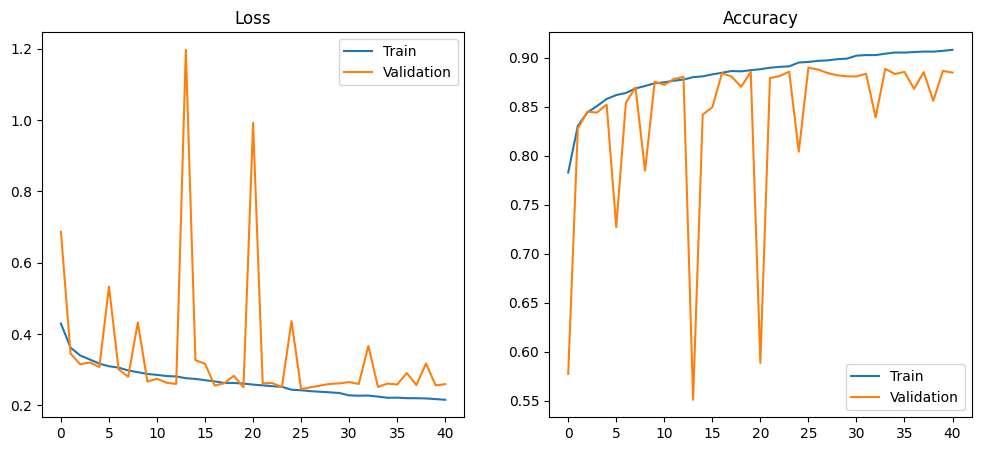

In [ ]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "fpn" / "fpn_loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()